In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
url_data = "https://archive.ics.uci.edu/ml/machine-learning-databases/audiology/audiology.standardized.data"
df = pd.read_csv(url_data, header=None, na_values="?")

df = df.dropna(axis=1, thresh=len(df)*0.5)
df = df.dropna()

df.head()

,0,1,2,3,4,5,6,8,9,10,...,61,62,63,64,65,66,67,68,69,70
4,t,mild,f,normal,normal,mild,t,f,f,f,...,f,f,good,t,a,f,f,f,p5,cochlear_age
5,t,mild,f,normal,normal,mild,t,f,f,f,...,f,f,very_good,t,a,f,f,f,p6,cochlear_age
6,f,mild,f,normal,normal,mild,t,f,f,f,...,f,f,good,t,a,f,f,f,p7,cochlear_unknown
7,f,mild,f,normal,normal,mild,t,f,f,f,...,f,f,very_good,t,a,f,f,f,p8,cochlear_unknown
9,t,mild,f,elevated,absent,mild,t,f,f,f,...,f,f,good,t,a,f,f,f,p10,cochlear_age


In [3]:
X = df.iloc[:, :-2]
y = df.iloc[:, -1]

X = pd.get_dummies(X)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
best_model = DecisionTreeClassifier(random_state=42)
best_model.fit(X_train, y_train)
predictions = best_model.predict(X_test)

In [6]:
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, predictions, zero_division=0))

Accuracy: 0.5416666666666666

Classification Report:
                        precision    recall  f1-score   support

      acoustic_neuroma       0.00      0.00      0.00         0
          cochlear_age       0.83      1.00      0.91         5
cochlear_age_and_noise       1.00      1.00      1.00         2
   cochlear_poss_noise       0.00      0.00      0.00         3
      cochlear_unknown       0.57      0.67      0.62         6
   conductive_fixation       1.00      1.00      1.00         1
 mixed_poss_central_om       0.00      0.00      0.00         1
   mixed_poss_noise_om       0.00      0.00      0.00         2
            normal_ear       0.33      1.00      0.50         1
          poss_central       0.00      0.00      0.00         1
     possible_menieres       0.00      0.00      0.00         2
 retrocochlear_unknown       0.00      0.00      0.00         0

              accuracy                           0.54        24
             macro avg       0.31      0.39      

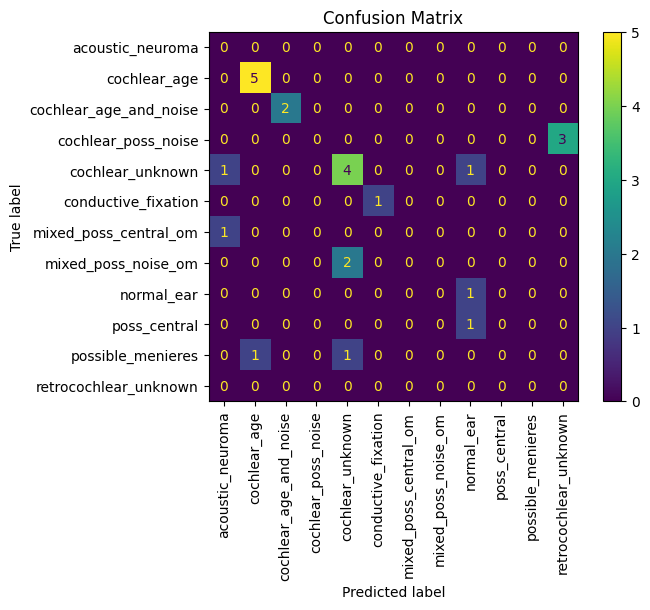

In [7]:
ConfusionMatrixDisplay.from_predictions(y_test, predictions, xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()



**Research Question:** Can a small set of audiological test results reliably predict the type of hearing disorder a patient has?

**Answer:** The Decision Tree model achieved an accuracy of approximately 0.5416666666666666%
on the test set. This suggests that audiological test results do carry meaningful signal for predicting
diagnosis category, though performance varies across the different diagnosis classes — some
categories with more training examples were predicted more reliably than rarer categories, as
shown in the classification report and confusion matrix. With a larger dataset and more balanced
class representation, the model could likely perform even better.